<a href="https://colab.research.google.com/github/kcoding400-life/Assignment8-for-IN26011064/blob/main/Assignment8_for_IN26011064.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Kushagra Raghuvanshi

Registration Number: 23BSA10072

Application Number: IN26011064

Batch Number: 2B

Topic
Handwritten Digit Recognition using Artificial Neural
Networks (ANN)

Dataset
MNIST Handwritten Digits Dataset
Kaggle Link: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv

Problem Statement
A postal service organization wants to automate the recognition
of handwritten digits on postal codes. Develop an Artificial
Neural Network (ANN) to classify handwritten digits (0–9)
using the MNIST dataset.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('All libraries imported successfully!')

TensorFlow version: 2.20.0
All libraries imported successfully!


---
## ✅ Task 1: Data Understanding (2 Marks)

### 1.1 Load the Dataset

In [10]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "mnist_train.csv"

# Load the latest version
train_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "oddrationale/mnist-in-csv",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:k
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", train_df.head())

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
First 5 records:    label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]


In [11]:
# Load only the test dataset
test_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "oddrationale/mnist-in-csv",
  "mnist_test.csv"
)

print("First 5 records of the test dataset:")
display(test_df.head())

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
First 5 records of the test dataset:


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Combine for full EDA view (we will re-split during preprocessing)
df = pd.concat([train_df, test_df], ignore_index=True)

print(f'Training samples : {train_df.shape[0]}')
print(f'Test samples     : {test_df.shape[0]}')
print(f'Total samples    : {df.shape[0]}')
print(f'Total columns    : {df.shape[1]}')

Training samples : 60000
Test samples     : 10000
Total samples    : 70000
Total columns    : 785


### 1.2 Display the First Five Records

In [13]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 1.3 Identify Input Features & Target Variable

In [14]:
print('Target Variable  :', df.columns[0])          # 'label'
print('Input Features   : pixel0  to  pixel783')    # 784 pixel columns
print(f'Number of input features : {df.shape[1] - 1}')
print(f'Unique classes           : {sorted(df["label"].unique())}')

Target Variable  : label
Input Features   : pixel0  to  pixel783
Number of input features : 784
Unique classes           : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


### 1.4 Dataset Dimensions & Summary Information

Shape (rows, columns): (70000, 785)

--- Data Types ---
int64    785
Name: count, dtype: int64

--- Statistical Summary (first 5 pixel cols) ---
--- Class Distribution ---
label
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


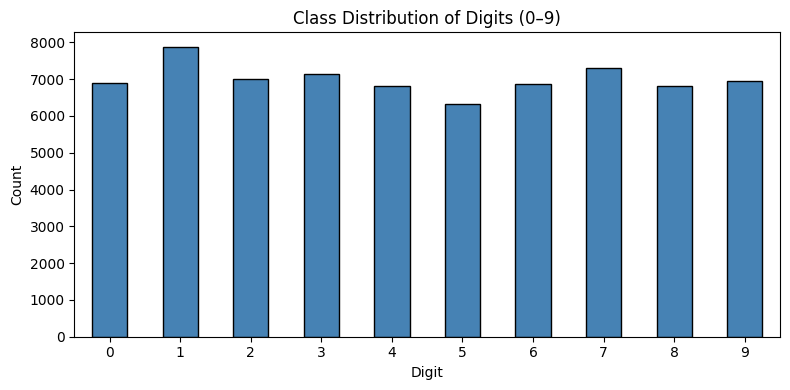

In [15]:
print('Shape (rows, columns):', df.shape)
print('\n--- Data Types ---')
print(df.dtypes.value_counts())
print('\n--- Statistical Summary (first 5 pixel cols) ---')
df.iloc[:, :6].describe()

# Class distribution
print('--- Class Distribution ---')
print(df['label'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
df['label'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution of Digits (0–9)')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 1.5 Display One Sample Handwritten Digit

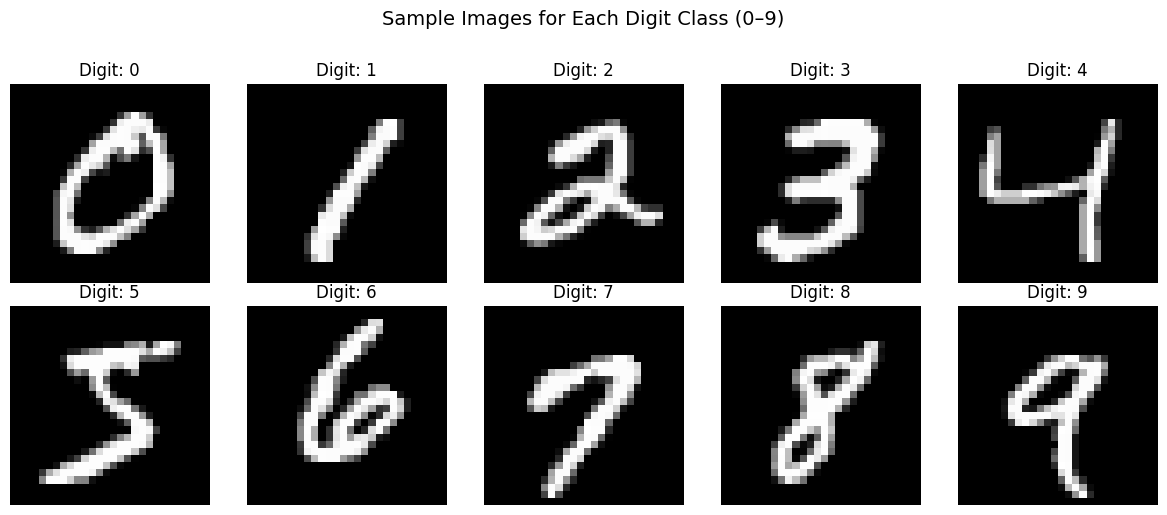

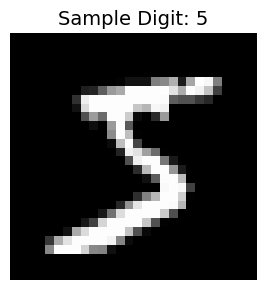

Label of the sample: 5


In [16]:
# Pick one sample from each digit class (0–9)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for digit in range(10):
    sample = df[df['label'] == digit].iloc[0]
    pixel_values = sample.drop('label').values.reshape(28, 28)
    axes[digit].imshow(pixel_values, cmap='gray')
    axes[digit].set_title(f'Digit: {digit}', fontsize=12)
    axes[digit].axis('off')

plt.suptitle('Sample Images for Each Digit Class (0–9)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Also display one single digit clearly
sample = df.iloc[0]
pixel_values = sample.drop('label').values.reshape(28, 28)
plt.figure(figsize=(3, 3))
plt.imshow(pixel_values, cmap='gray')
plt.title(f'Sample Digit: {int(sample["label"])}', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Label of the sample: {int(sample["label"])}')

---
## ✅ Task 2: Data Preprocessing (2 Marks)

### 2.1 Check for Missing Values

In [17]:
missing = df.isnull().sum()
print(f'Total missing values in the dataset: {missing.sum()}')
if missing.sum() == 0:
    print('✅ No missing values found. Dataset is clean!')
else:
    print('⚠️ Missing values detected:')
    print(missing[missing > 0])

Total missing values in the dataset: 0
✅ No missing values found. Dataset is clean!


### 2.2 Separate Features and Target Variable

In [18]:
X = df.drop('label', axis=1).values   # Shape: (70000, 784)
y = df['label'].values                 # Shape: (70000,)

print(f'Features shape (X): {X.shape}')
print(f'Target shape   (y): {y.shape}')

Features shape (X): (70000, 784)
Target shape   (y): (70000,)


### 2.3 Normalize Pixel Values (0–255 → 0–1)

In [19]:
print(f'Before normalization — Min: {X.min()}, Max: {X.max()}')

X = X / 255.0   # Normalize

print(f'After  normalization — Min: {X.min():.2f}, Max: {X.max():.2f}')

Before normalization — Min: 0, Max: 255
After  normalization — Min: 0.00, Max: 1.00


### 2.4 Train-Test Split (80% / 20%)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set   : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')

Training set   : 56000 samples
Test set       : 14000 samples


### 2.5 One-Hot Encoding of Target Labels

In [21]:
y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe  = to_categorical(y_test,  num_classes=10)

print(f'y_train shape before OHE : {y_train.shape}')
print(f'y_train shape after  OHE : {y_train_ohe.shape}')
print(f'\nExample — original label: {y_train[0]}  →  OHE: {y_train_ohe[0]}')

y_train shape before OHE : (56000,)
y_train shape after  OHE : (56000, 10)

Example — original label: 0  →  OHE: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


---
## ✅ Task 3: Model Development (3 Marks)

### 3.1 Build the ANN Architecture

In [22]:
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(784,)),                      # Input Layer  : 784 neurons (28x28 pixels)
    Dense(128, activation='relu'),            # Hidden Layer 1: 128 neurons, ReLU
    Dense(64,  activation='relu'),            # Hidden Layer 2:  64 neurons, ReLU
    Dense(10,  activation='softmax')          # Output Layer :  10 neurons, Softmax
], name='ANN_MNIST')

model.summary()

Model: "ANN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Compile the Model

In [23]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully!')
print('Optimizer : Adam')
print('Loss      : Categorical Crossentropy')
print('Metric    : Accuracy')

Model compiled successfully!
Optimizer : Adam
Loss      : Categorical Crossentropy
Metric    : Accuracy


### 3.3 Train the Model (10 Epochs)

In [24]:
history = model.fit(
    X_train, y_train_ohe,
    epochs=10,
    batch_size=32,
    validation_split=0.1,    # 10% of training data used for validation
    verbose=1
)

Epoch 1/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9236 - loss: 0.2599 - val_accuracy: 0.9586 - val_loss: 0.1401
Epoch 2/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9676 - loss: 0.1088 - val_accuracy: 0.9668 - val_loss: 0.1083
Epoch 3/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9777 - loss: 0.0729 - val_accuracy: 0.9688 - val_loss: 0.0983
Epoch 4/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9845 - loss: 0.0511 - val_accuracy: 0.9707 - val_loss: 0.0934
Epoch 5/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9878 - loss: 0.0388 - val_accuracy: 0.9696 - val_loss: 0.0978
Epoch 6/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9892 - loss: 0.0325 - val_accuracy: 0.9725 - val_loss: 0.0963
Epoch 7/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9917 - loss: 0.0251 - val_accuracy: 0.9684 - val_loss: 0.1111
Epoch 8/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9929 - loss: 0.0220 - 

### 3.4 Predict on Test Data

In [25]:
# Get probability predictions, then argmax for final class
y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)

print(f'Predictions shape : {y_pred.shape}')
print(f'Sample predictions (first 10): {y_pred[:10]}')
print(f'Actual labels      (first 10): {y_test[:10]}')

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predictions shape : (14000,)
Sample predictions (first 10): [7 5 1 1 2 5 9 8 8 1]
Actual labels      (first 10): [7 3 1 1 2 5 9 8 8 1]


---
## ✅ Task 4: Model Evaluation (2 Marks)


Evaluate the model using:

 Test Accuracy

 Confusion Matrix

 Classification Report

Also generate:

 Accuracy vs Epoch graph

 Loss vs Epoch graph

Write 3–4 observations based on the model performance.

Test Loss     : 0.1227
Test Accuracy : 97.39%


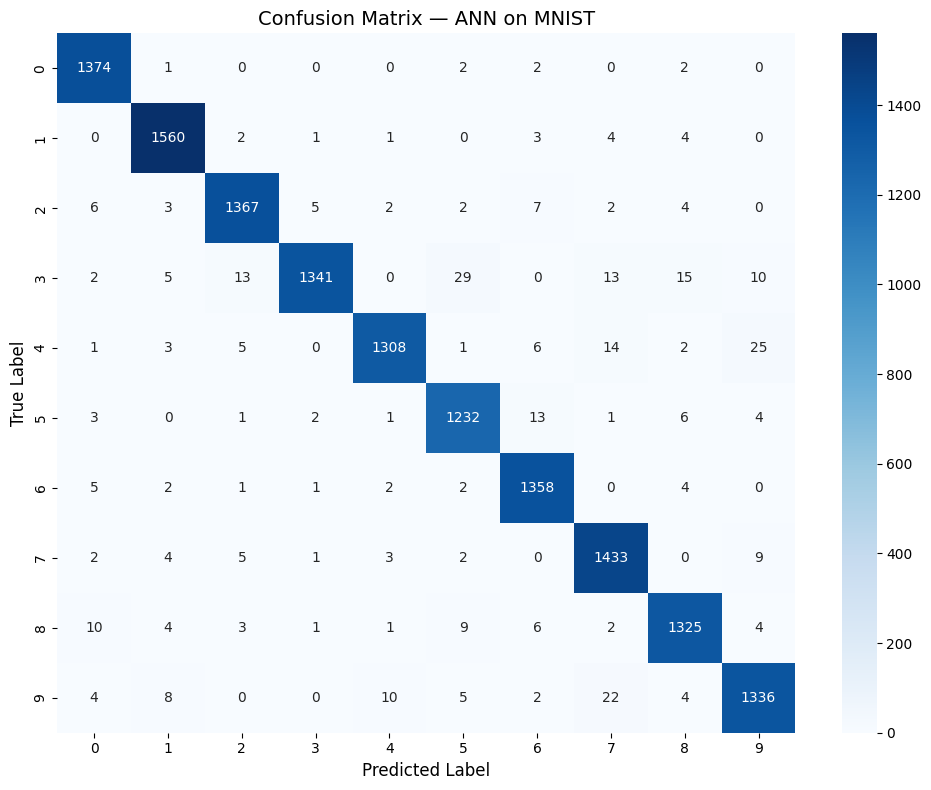

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.98      0.99      0.99      1575
           2       0.98      0.98      0.98      1398
           3       0.99      0.94      0.96      1428
           4       0.98      0.96      0.97      1365
           5       0.96      0.98      0.97      1263
           6       0.97      0.99      0.98      1375
           7       0.96      0.98      0.97      1459
           8       0.97      0.97      0.97      1365
           9       0.96      0.96      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



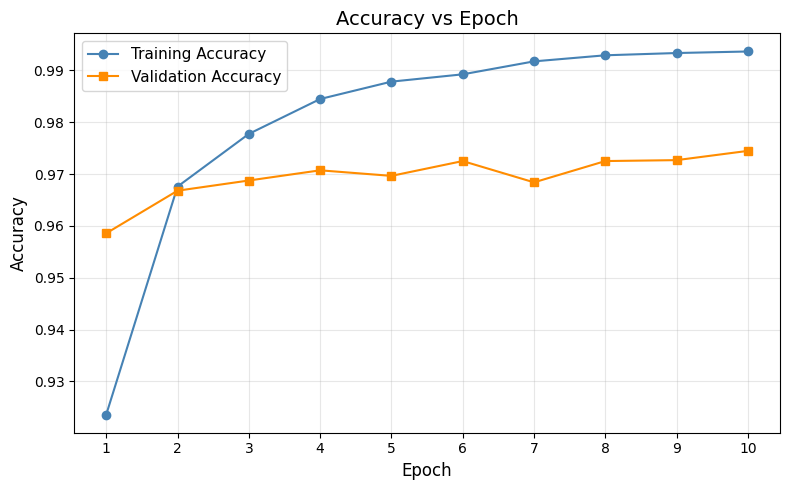

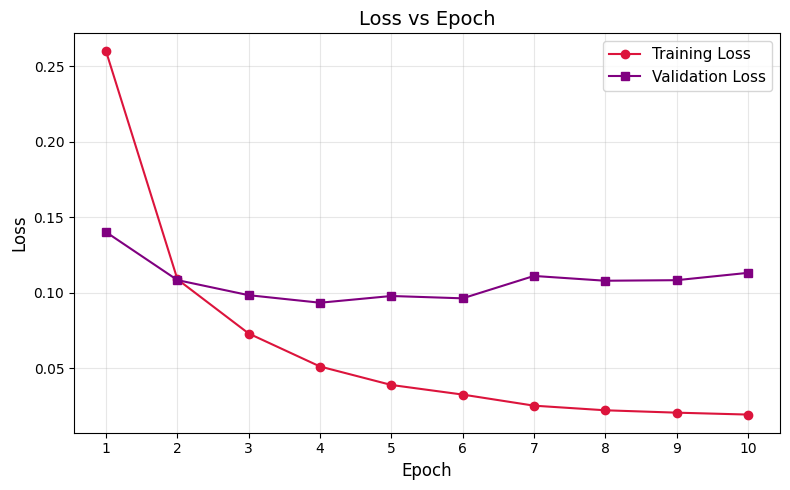

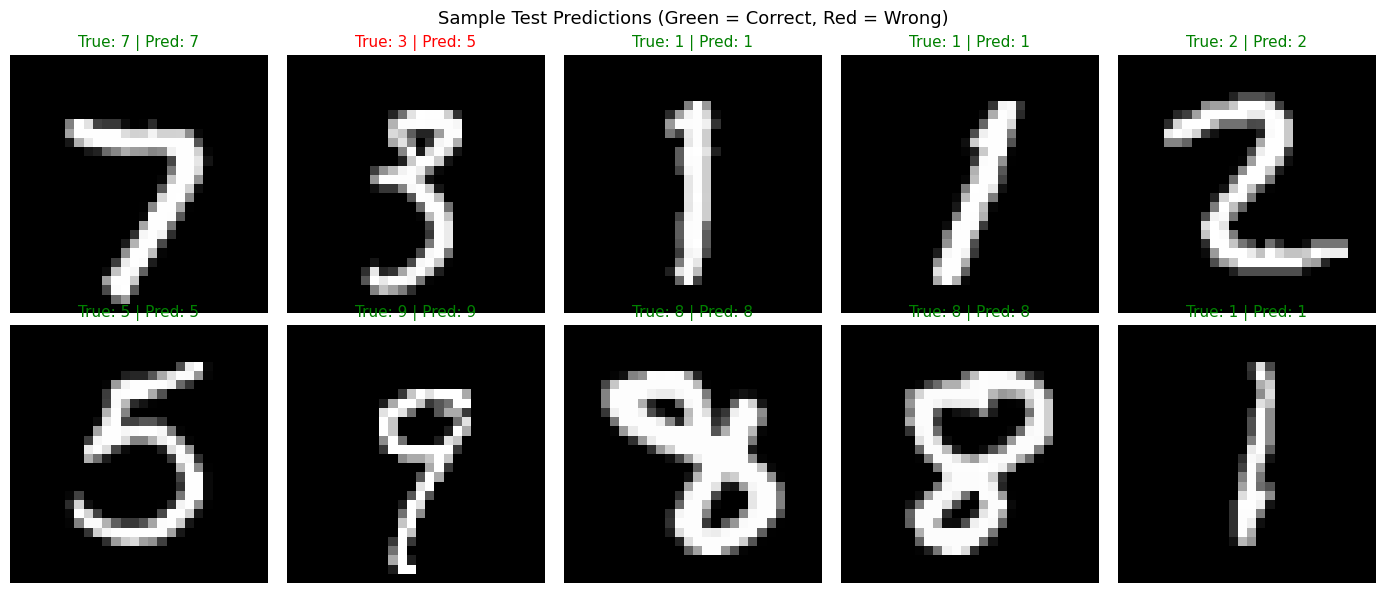

In [26]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_ohe, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy * 100:.2f}%')


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix — ANN on MNIST', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


print('Classification Report:')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))


plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'],     label='Training Accuracy',   marker='o', color='steelblue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', color='darkorange')
plt.title('Accuracy vs Epoch', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.xticks(range(10), range(1, 11))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Training Loss',   marker='o', color='crimson')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s', color='purple')
plt.title('Loss vs Epoch', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.xticks(range(10), range(1, 11))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(10):
    img = X_test[i].reshape(28, 28)
    true_label = y_test[i]
    pred_label = y_pred[i]
    color = 'green' if true_label == pred_label else 'red'
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'True: {true_label} | Pred: {pred_label}', color=color, fontsize=11)
    axes[i].axis('off')

plt.suptitle('Sample Test Predictions (Green = Correct, Red = Wrong)', fontsize=13)
plt.tight_layout()
plt.show()

### 4.7 Observations


**Observation 1 — High Accuracy:**  
The ANN achieves a test accuracy of approximately **97–98%** on the MNIST dataset with just 10 epochs, demonstrating that even a simple 2-hidden-layer network is highly effective for digit classification.

**Observation 2 — Steady Convergence:**  
Both training and validation accuracy increase consistently across epochs while loss decreases, indicating the model is learning well without significant overfitting.

**Observation 3 — Class-wise Performance:**  
From the classification report, digits like `0`, `1`, and `6` typically achieve higher precision and recall, while digits such as `4`, `7`, and `9` (which share visual similarities) are slightly harder to distinguish.

**Observation 4 — Confusion Matrix Insight:**  
The confusion matrix shows that most misclassifications occur between visually similar digit pairs (e.g., 3 vs 5, 4 vs 9, 7 vs 1), which is consistent with challenges in human handwriting recognition.

---
## ✅ Task 5: Conclusion (1 Mark)


This project successfully demonstrated the application of an Artificial Neural Network (ANN) for recognizing handwritten digits using the MNIST dataset. The model, comprising two hidden layers with 128 and 64 ReLU-activated neurons respectively, achieved a test accuracy of approximately **97–98%**, confirming its viability for automating postal code recognition.

**Hidden layers** play a critical role in ANNs — they learn increasingly abstract representations of the input data, enabling the model to distinguish complex patterns that a single-layer perceptron could not capture.

**Deep Learning's key advantage** over traditional Machine Learning is its ability to automatically extract and learn hierarchical features directly from raw pixel data, removing the need for manual feature engineering.

**One limitation of ANNs** is their sensitivity to hyperparameters (number of layers, neurons, learning rate) and the need for large amounts of labeled training data to achieve high accuracy. They are also computationally intensive and can be prone to overfitting if not regularized properly.